In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import os
from pathlib import Path
from PIL import Image
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [ ]:
data_dir = Path('C:\Python\ML Intro\Projects\Medical Image Classification\data\chest_xray')
train_dir = data_dir/'train'
val_dir = data_dir/'val'
test_dir = data_dir/'test'
# Verify paths exits
print("Train directory exists:", train_dir.exists())
print("Val directory exists:", val_dir.exists())
print("Test directory exists:", test_dir.exists())


Train directory exists: True
Val directory exists: True
Test directory exists: True


In [21]:
def count_images(directory):
    "Count IMages In each Class"
    counts = {}
    for class_name in ['NORMAL','PNEUMONIA']:
        class_path = directory/class_name
        if class_path.exists():
            count = len(list(class_path.glob('*.jpeg'))) + \
                    len(list(class_path.glob('*.jpg'))) + \
                    len(list(class_path.glob('*.png'))) 
            counts[class_name] = count

    return counts

In [22]:
train_counts = count_images(train_dir)
val_counts = count_images(val_dir)
test_counts = count_images(test_dir)

summary_df = pd.DataFrame({
    'Train':train_counts,
    'Validation':val_counts,
    'Test':test_counts
})
print("\nDataset Summary:")
print(summary_df)
print("\n Total images:", summary_df.sum().sum())


Dataset Summary:
           Train  Validation  Test
NORMAL      1341           8   234
PNEUMONIA   3875           8   390

 Total images: 5856


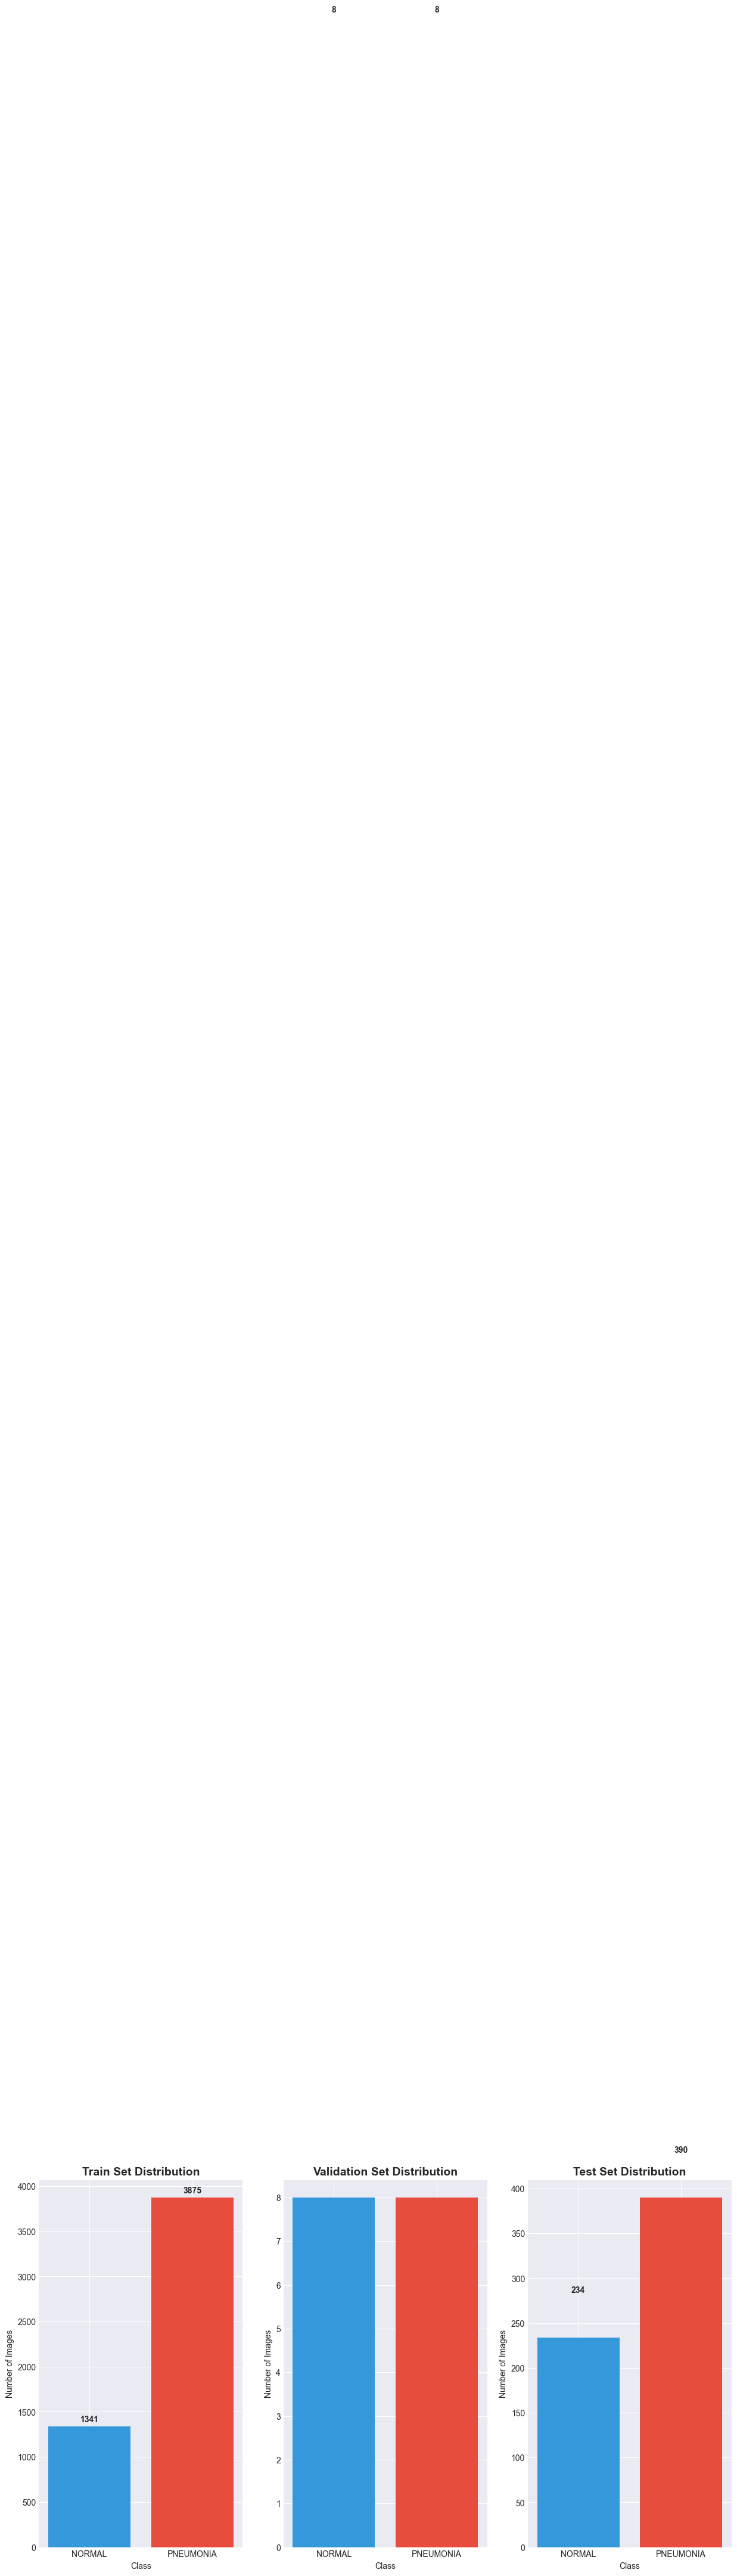


Class Imbalance Ratio (Train):
PNEUMONIA/NORMAL = 2.89:1


In [23]:
# Plot class distribution
fig, axes = plt.subplots(1, 3, figsize=(15, 8))

for idx, (split_name, counts) in enumerate([
    ('Train', train_counts),
    ('Validation', val_counts),
    ('Test', test_counts)
]):
    axes[idx].bar(counts.keys(), counts.values(), color=['#3498db', '#e74c3c'])
    axes[idx].set_title(f'{split_name} Set Distribution', fontsize=14, fontweight='bold')
    axes[idx].set_ylabel('Number of Images')
    axes[idx].set_xlabel('Class')
    
    # Add count labels on bars
    for i, (class_name, count) in enumerate(counts.items()):
        axes[idx].text(i, count + 50, str(count), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig("C:/Python/ML Intro/Projects/Medical Image Classification/results/plots/class_distribution.png", dpi=300, bbox_inches='tight')
plt.show()

# Calculate imbalance ratio
print(f"\nClass Imbalance Ratio (Train):")
print(f"PNEUMONIA/NORMAL = {train_counts['PNEUMONIA']/train_counts['NORMAL']:.2f}:1")

In [ ]:
def plot_sample_images(directory, num_samples=4):
    """Plot sample images from each class"""
    fig, axes = plt.subplots(2, num_samples, figsize=(16, 8))
    
    for i, class_name in enumerate(['NORMAL', 'PNEUMONIA']):
        class_path = directory / class_name
        
        # Get random sample of images
        image_files = list(class_path.glob('*.jpeg')) + list(class_path.glob('*.jpg'))
        samples = np.random.choice(image_files, num_samples, replace=False)
        
        for j, img_path in enumerate(samples):
            # Load image
            img = Image.open(img_path)
            
            # Plot
            axes[i, j].imshow(img, cmap='gray')
            axes[i, j].axis('off')
            
            if j == 0:
                axes[i, j].set_title(f'{class_name}\n{img.size}', 
                                    fontsize=12, fontweight='bold', loc='left')
            else:
                axes[i, j].set_title(f'{img.size}', fontsize=10)
    
    plt.suptitle('Sample X-ray Images from Training Set', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('C:/Python/ML Intro/Projects/Medical Image Classification/results/plots/sample_images.png', dpi=300, bbox_inches='tight')

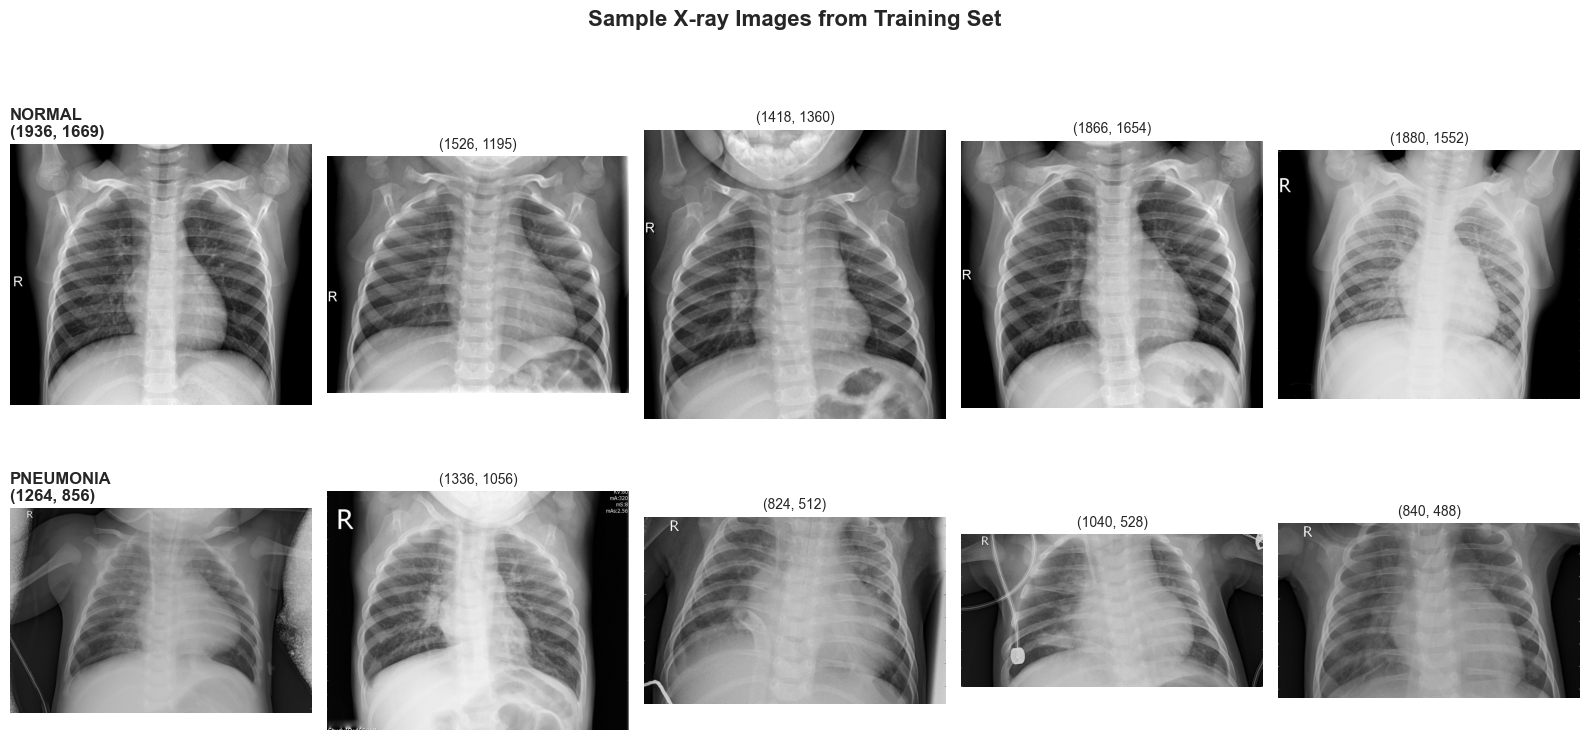

In [28]:
plot_sample_images(train_dir,num_samples=5)

 Analyzing image dimensions (this may take a minute)...

 Image Size Statistics:
             width      height  aspect_ratio
count  1000.000000  1000.00000   1000.000000
mean   1436.801000  1106.05000      1.372316
std     385.086228   422.41603      0.248989
min     415.000000   151.00000      0.898148
25%    1152.000000   767.75000      1.197168
50%    1432.000000  1081.00000      1.325869
75%    1688.000000  1380.75000      1.500000
max    2916.000000  2628.00000      3.271523


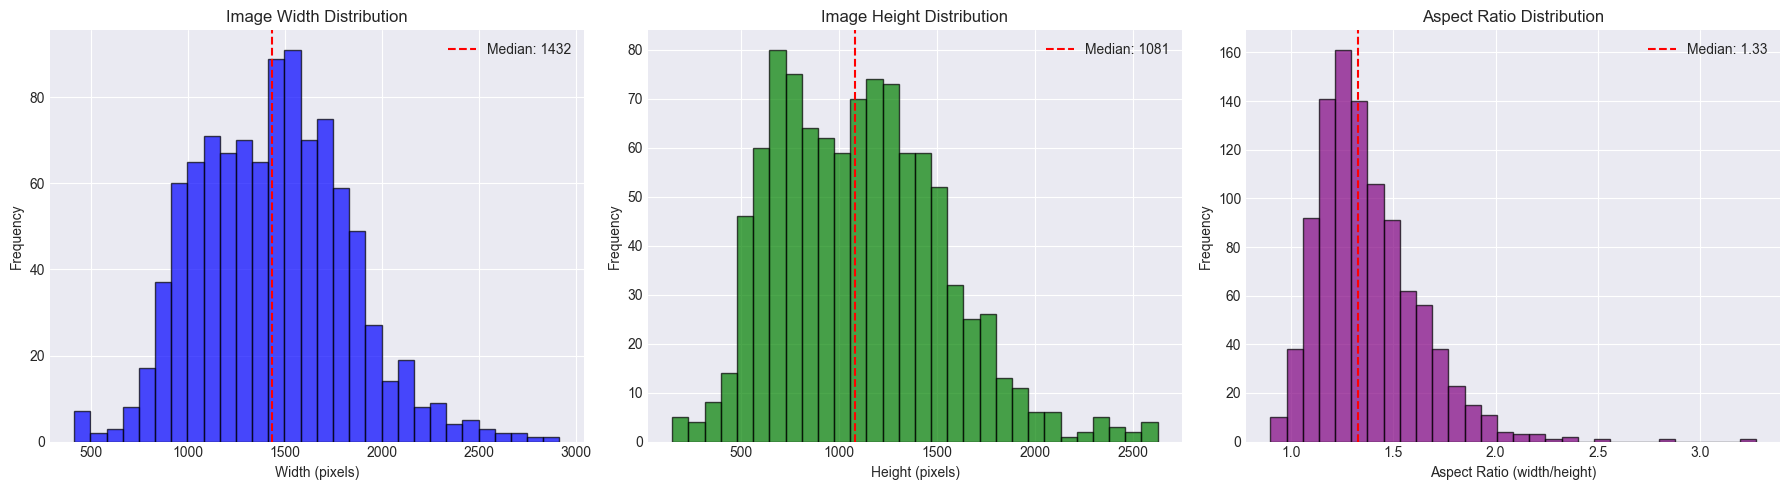


 Recommendation: Resize images to 224x224 for transfer learning models


In [ ]:
def analyze_image_sizes(directory, sample_size=500):
    """Analyze image dimensions in dataset"""
    sizes = []
    
    for class_name in ['NORMAL', 'PNEUMONIA']:
        class_path = directory / class_name
        image_files = list(class_path.glob('*.jpeg')) + list(class_path.glob('*.jpg'))
        
        # Sample random images
        sampled_files = np.random.choice(image_files, 
                                        min(sample_size, len(image_files)), 
                                        replace=False)
        
        for img_path in sampled_files:
            img = Image.open(img_path)
            sizes.append({
                'class': class_name,
                'width': img.size[0],
                'height': img.size[1],
                'aspect_ratio': img.size[0] / img.size[1]
            })
    
    return pd.DataFrame(sizes)

# Analyze
print(" Analyzing image dimensions (this may take a minute)...")
size_df = analyze_image_sizes(train_dir, sample_size=500)

print("\n Image Size Statistics:")
print(size_df.describe())

# Plot dimension distribution
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Width distribution
axes[0].hist(size_df['width'], bins=30, alpha=0.7, color='blue', edgecolor='black')
axes[0].set_xlabel('Width (pixels)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Image Width Distribution')
axes[0].axvline(size_df['width'].median(), color='red', linestyle='--', 
               label=f'Median: {size_df["width"].median():.0f}')
axes[0].legend()

# Height distribution
axes[1].hist(size_df['height'], bins=30, alpha=0.7, color='green', edgecolor='black')
axes[1].set_xlabel('Height (pixels)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Image Height Distribution')
axes[1].axvline(size_df['height'].median(), color='red', linestyle='--',
               label=f'Median: {size_df["height"].median():.0f}')
axes[1].legend()

# Aspect ratio
axes[2].hist(size_df['aspect_ratio'], bins=30, alpha=0.7, color='purple', edgecolor='black')
axes[2].set_xlabel('Aspect Ratio (width/height)')
axes[2].set_ylabel('Frequency')
axes[2].set_title('Aspect Ratio Distribution')
axes[2].axvline(size_df['aspect_ratio'].median(), color='red', linestyle='--',
               label=f'Median: {size_df["aspect_ratio"].median():.2f}')
axes[2].legend()

plt.tight_layout()
plt.savefig('C:/Python/ML Intro/Projects/Medical Image Classification/results/plots/image_dimensions.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n Recommended Resizing to 224x224 for transfer learning models")

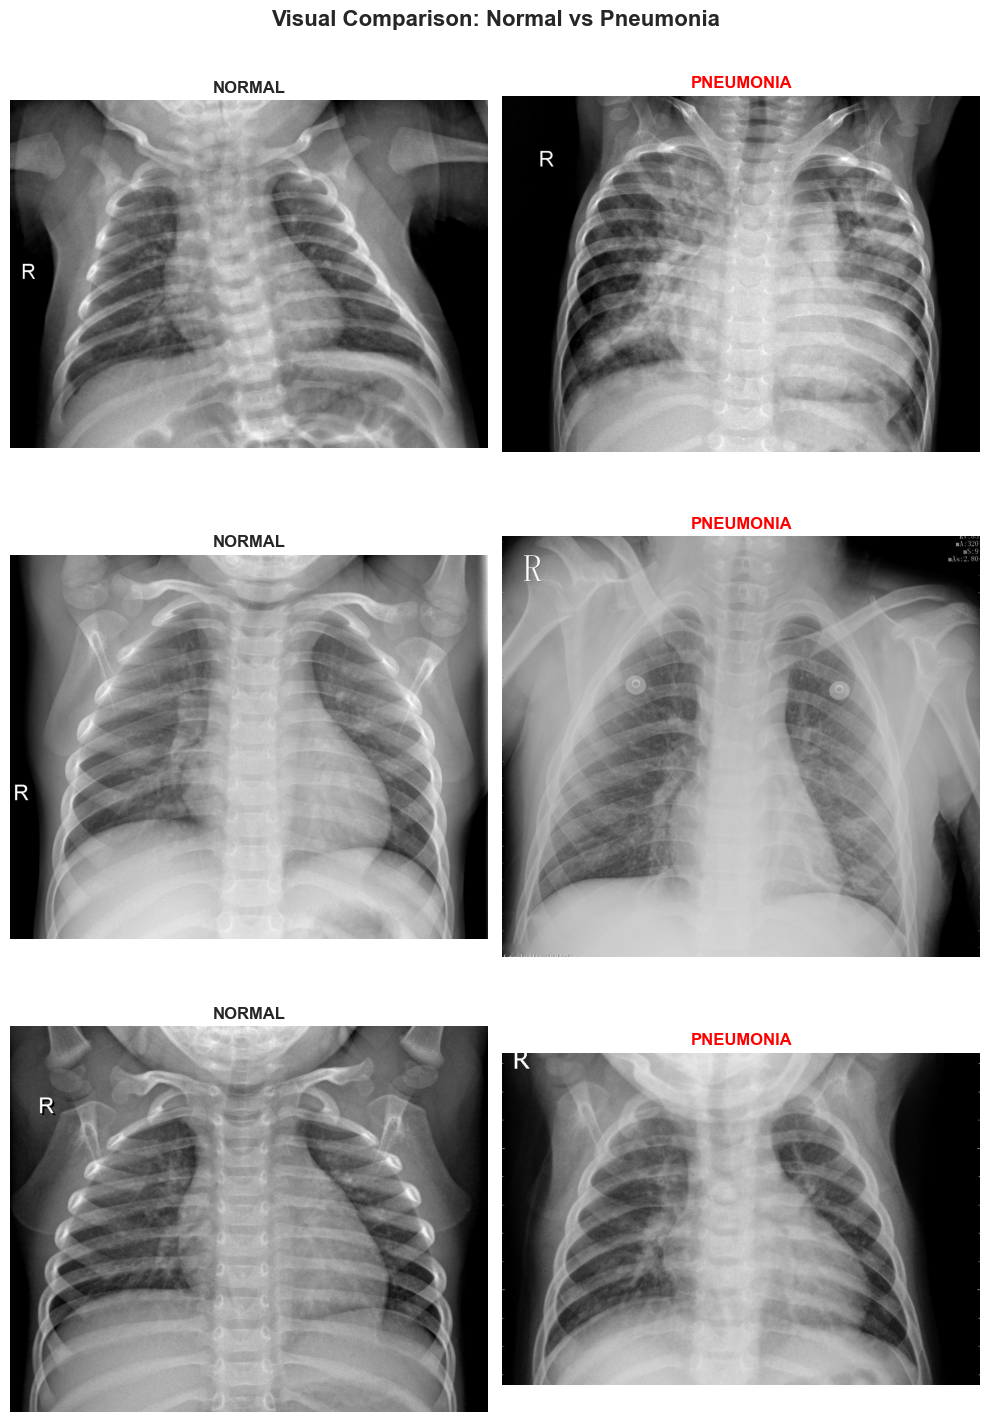

In [31]:
# Side-by-side comparison
fig, axes = plt.subplots(3, 2, figsize=(10, 15))

for i in range(3):
    # Normal
    normal_files = list((train_dir / 'NORMAL').glob('*.jpeg'))
    normal_img = Image.open(np.random.choice(normal_files))
    axes[i, 0].imshow(normal_img, cmap='gray')
    axes[i, 0].set_title('NORMAL', fontweight='bold', fontsize=12)
    axes[i, 0].axis('off')
    
    # Pneumonia
    pneumonia_files = list((train_dir / 'PNEUMONIA').glob('*.jpeg'))
    pneumonia_img = Image.open(np.random.choice(pneumonia_files))
    axes[i, 1].imshow(pneumonia_img, cmap='gray')
    axes[i, 1].set_title('PNEUMONIA', fontweight='bold', fontsize=12, color='red')
    axes[i, 1].axis('off')

plt.suptitle('Visual Comparison: Normal vs Pneumonia', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('C:/Python/ML Intro/Projects/Medical Image Classification/results/plots/comparison.png', dpi=300, bbox_inches='tight')
plt.show()

In [32]:
print("=" * 60)
print(" WEEK 1 EDA SUMMARY")
print("=" * 60)
print(f"\nTotal Images: {summary_df.sum().sum()}")
print(f"   - Train: {summary_df['Train'].sum()}")
print(f"   - Validation: {summary_df['Validation'].sum()}")
print(f"   - Test: {summary_df['Test'].sum()}")

print(f"\n  Class Imbalance:")
print(f"   - Train PNEUMONIA/NORMAL ratio: {train_counts['PNEUMONIA']/train_counts['NORMAL']:.2f}:1")
print(f"   - Action needed: Use class weights during training")

print(f"\n Image Dimensions:")
print(f"   - Average width: {size_df['width'].mean():.0f} px")
print(f"   - Average height: {size_df['height'].mean():.0f} px")
print(f"   - Recommended resize: 224x224 (standard for transfer learning)")

print(f"\n Next Steps for Week 2:")
print("   1. Create data generators with augmentation")
print("   2. Build baseline CNN model")
print("   3. Train and evaluate baseline")
print("   4. Save results for comparison")
print("=" * 60)

 WEEK 1 EDA SUMMARY

Total Images: 5856
   - Train: 5216
   - Validation: 16
   - Test: 624

  Class Imbalance:
   - Train PNEUMONIA/NORMAL ratio: 2.89:1
   - Action needed: Use class weights during training

 Image Dimensions:
   - Average width: 1437 px
   - Average height: 1106 px
   - Recommended resize: 224x224 (standard for transfer learning)

 Next Steps for Week 2:
   1. Create data generators with augmentation
   2. Build baseline CNN model
   3. Train and evaluate baseline
   4. Save results for comparison
